<a href="https://colab.research.google.com/github/MamidiPravallikaReddy/DL_LAB/blob/main/DL_week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)

--2026-04-06 15:21:19--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  36.9MB/s    in 8.1s    

2026-04-06 15:21:27 (21.5 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

--2026-04-06 15:21:27--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat’

test_32x32.mat      100%[===================>]  61.30M  14.2MB/s    in 5.8s    

2026-04-06 15:21:33 (10.5 MB/s) - ‘test_32x32.mat’ saved [64275384/64

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7278 - loss: 0.8880
Epoch 2/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8622 - loss: 0.4973
Epoch 3/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8785 - loss: 0.4276
Epoch 4/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8900 - loss: 0.3852
Epoch 5/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8963 - loss: 0.3573
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step


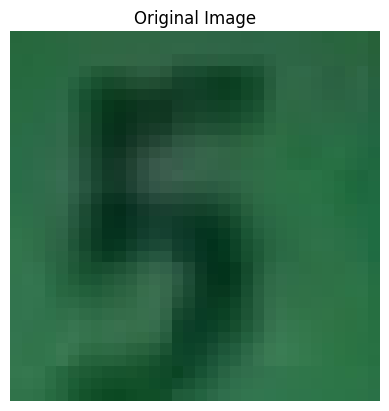

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


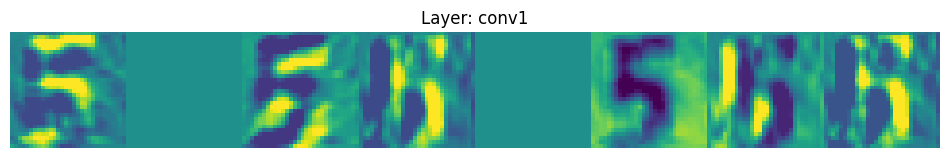

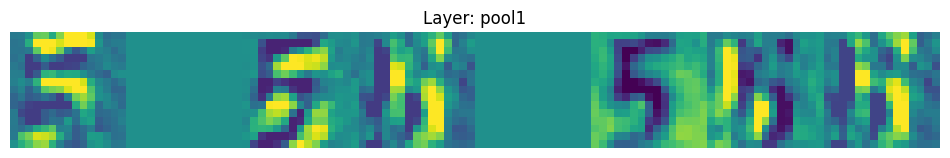

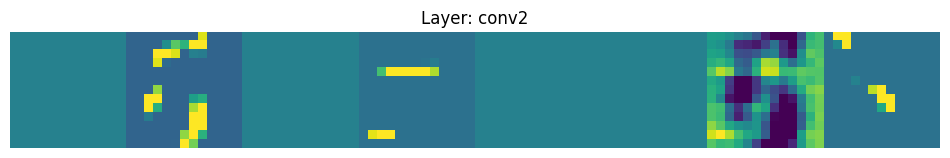

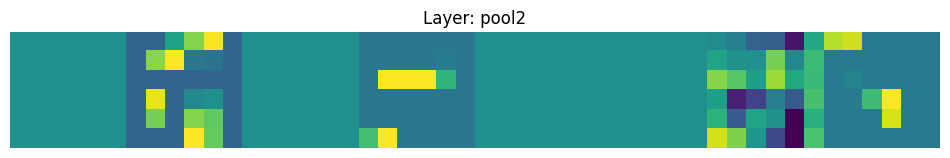

814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Total misclassified images: 3510


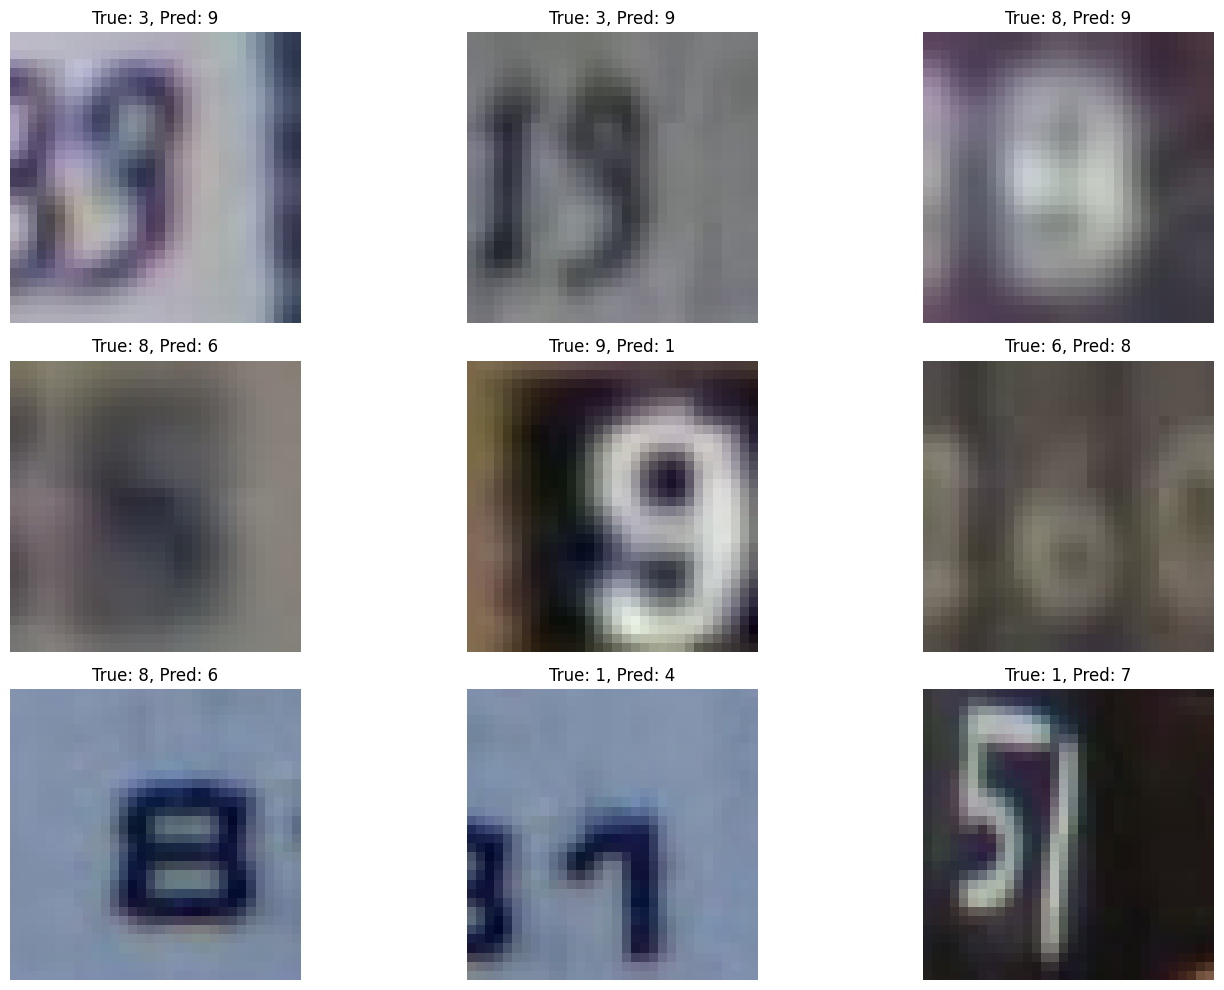

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import scipy.io
from tensorflow.keras import layers, models

!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train_data = scipy.io.loadmat('train_32x32.mat')
test_data = scipy.io.loadmat('test_32x32.mat')

X_train = train_data['X']
Y_train = train_data['y']

X_test = test_data['X']
Y_test = test_data['y']

X_train = np.transpose(X_train, (3,0,1,2))
X_test = np.transpose(X_test, (3,0,1,2))

Y_train[Y_train == 10] = 0
Y_test[Y_test == 10] = 0

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), activation='relu', name="conv1"),
    layers.MaxPooling2D((2,2), name="pool1"),

    layers.Conv2D(64, (3,3), activation='relu', name="conv2"),
    layers.MaxPooling2D((2,2), name="pool2"),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

model.fit(X_train, Y_train, epochs=5, batch_size=32)

_ = model.predict(X_train[:1])

layer_outputs = [layer.output for layer in model.layers
                 if "conv" in layer.name or "pool" in layer.name]

feature_map_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

index = 0
img = X_test[index]

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

feature_maps = feature_map_model.predict(img)

def plot_feature_maps(feature_maps, layer_names):
    for fmap, layer_name in zip(feature_maps, layer_names):

        num_filters = fmap.shape[-1]
        size = fmap.shape[1]

        n_filters = min(num_filters, 8)
        display_grid = np.zeros((size, size * n_filters))

        for i in range(n_filters):
            x = fmap[0, :, :, i]

            x -= x.mean()
            x /= (x.std() + 1e-5)
            x *= 64
            x += 128
            x = np.clip(x, 0, 255).astype('uint8')

            display_grid[:, i * size : (i + 1) * size] = x

        plt.figure(figsize=(12, 3))
        plt.title(f"Layer: {layer_name}")
        plt.imshow(display_grid, cmap='viridis')
        plt.axis('off')
        plt.show()

layer_names = [layer.name for layer in model.layers
               if "conv" in layer.name or "pool" in layer.name]

plot_feature_maps(feature_maps, layer_names)

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

Y_test_flat = Y_test.flatten()

misclassified_indices = np.where(predicted_classes != Y_test_flat)[0]

print("Total misclassified images:", len(misclassified_indices))

plt.figure(figsize=(15, 10))

num_images = min(9, len(misclassified_indices))

for i in range(num_images):
    idx = misclassified_indices[i]

    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {Y_test_flat[idx]}, Pred: {predicted_classes[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()